# <center>Hotel Industry Data Analysis</center>
### <center>Python Project</center>

### Step 1: Import Required Libraries
We will import `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib` for creating visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Load the Dataset
We load the `hotel.csv` file into a pandas DataFrame. We also use `encoding='latin1'` to handle potential special characters often found in scraped data.

In [4]:
# Loading the dataset
df = pd.read_excel('hotel_analysis.xlsx')

# Confirming data is loaded
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Step 3: Initial Data Inspection
To understand what we are working with, we display the first few rows and the shape of the dataset. This helps us identify column names and sample values.

In [5]:
# Display first 5 rows
df.head()

,address,area,city,country,crawl_date,hotel_description,hotel_facilities,hotel_star_rating,landmark,property_name,property_type,room_count,room_facilities,room_type,state
0,"9th Mile, Kalimpong",Rishi Road-Highway 12,Kalimpong,INDIA,2016-08-16,"Hotel Jiwan Jyoti, Kalimpong is an ultimate st...",Travel:Travel Desk|Parking|Free Parking|Person...,1 Star hotel,"Rishi Road-Highway 12, Kalimpong",Hotel Jivan Jyoti,Hotel,9,Toiletries | Luggage Rack | Private Bathroom,Standard Room,WestBengal
1,"New Kalimati Road, Kasidih, Sakchi",NaN,Jamshedpur,INDIA,2016-08-16,Retire to the beautiful rooms of OYO Premium K...,Food &amp; Beverage:Bar|Restaurant|Basics:Inte...,3 Star hotel,", Jamshedpur",OYO Premium Kalimati Road Jamshedpur,NaN,15,Air Conditioning | Television | Toiletries Int...,Premium Room,Jharkhand
2,"Opposite Nagarpalika, Near Pushkarna Bera, Pos...",NaN,Jaisalmer,INDIA,2016-08-16,OYO Rooms Bera Road in Jaisalmer has a royal c...,Basics:Internet|Air Conditioning|Doorman|House...,3 Star hotel,", Jaisalmer",OYO Rooms Bera Road,NaN,15,Air Conditioning | Television | Refrigerator I...,Standard Room AC,Rajasthan
3,"11-3-11 Veterinary Hospital road,Ramarao peta",Cinema Road,Kakinada,INDIA,2016-08-16,Situated in quite part of the city yet close t...,Food &amp; Beverage:Bar|Restaurant|Coffee Shop...,3 Star hotel,"Cinema Road, Kakinada",Grand Kakinada by GRT Hotels,Hotel,85,Air Conditioning| Television| Iron| Mini Bar| ...,Business Room,AndhraPradesh
4,"Near Fort First Gate, Dhibbapara",Near Jaisalmer Golden Fort,Jaisalmer,INDIA,2016-08-16,"Hotel Gorakh Haveli, Jaisalmer, with hospitali...",Basics:Internet|Air Conditioning|Non-Smoking R...,3 Star hotel,"Near Jaisalmer Golden Fort, Jaisalmer",Hotel Gorakh Haveli,Hotel,17,Television| Internet / Broadband| Telephone| W...,Deluxe,Rajasthan


In [6]:
# Display dataset dimensions
print("\nDataset Shape (Rows, Columns):", df.shape)


Dataset Shape (Rows, Columns): (5000, 15)


### Step 4: Check for Missing Values and Data Types
It is crucial to check for null values and incorrect data types (like numbers stored as text) before analyzing. The `info()` method gives us this summary.

In [7]:
# checking information about columns and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   address            4995 non-null   object        
 1   area               4909 non-null   object        
 2   city               5000 non-null   object        
 3   country            5000 non-null   object        
 4   crawl_date         5000 non-null   datetime64[ns]
 5   hotel_description  4655 non-null   object        
 6   hotel_facilities   4964 non-null   object        
 7   hotel_star_rating  4746 non-null   object        
 8   landmark           5000 non-null   object        
 9   property_name      5000 non-null   object        
 10  property_type      2766 non-null   object        
 11  room_count         5000 non-null   int64         
 12  room_facilities    4938 non-null   object        
 13  room_type          4999 non-null   object        
 14  state   

### Step 5: Data Cleaning (Column Selection & Formatting)
The raw dataset contains many text-heavy columns (like descriptions and URLs) that we don't need for numerical analysis. We will:
1. Select only relevant columns.
2. Clean the `hotel_star_rating` column (e.g., converting "3 Star hotel" to just the number 3).
3. Drop rows with missing values to ensure accurate calculations.

In [8]:
# 1. Selecting only useful columns
columns_to_keep = ['property_name', 'city', 'state', 'hotel_star_rating', 'room_count', 'property_type']
df = df[columns_to_keep]

# 2. Extracting the numeric number from 'hotel_star_rating'
# Example: "3 Star hotel" -> 3
# We split the string and take the first part
df['rating_numeric'] = df['hotel_star_rating'].astype(str).str.split().str[0]

# Convert it to a number (coercing errors ensures non-numbers become NaN)
df['rating_numeric'] = pd.to_numeric(df['rating_numeric'], errors='coerce')

# 3. Drop rows where critical data is missing
df_clean = df.dropna()

print("Data Cleaned Successfully.")
df_clean.head()

Data Cleaned Successfully.


,property_name,city,state,hotel_star_rating,room_count,property_type,rating_numeric
0,Hotel Jivan Jyoti,Kalimpong,WestBengal,1 Star hotel,9,Hotel,1.0
3,Grand Kakinada by GRT Hotels,Kakinada,AndhraPradesh,3 Star hotel,85,Hotel,3.0
4,Hotel Gorakh Haveli,Jaisalmer,Rajasthan,3 Star hotel,17,Hotel,3.0
6,Hotel Navrang Kalka,Kalka,Haryana,2 Star hotel,8,Hotel,2.0
7,Hotel Gopi Nivas Grand,Kanyakumari,TamilNadu,3 Star hotel,70,Hotel,3.0


### Step 6: Core Numerical Analysis - Basic Statistics
We calculate the basic statistical summary (Mean, Min, Max, Count) for the numerical columns. This gives us a mathematically sound overview of the hotel industry in this dataset.

In [9]:
# Statistical summary of numerical columns (Room Counts and Ratings)
print(df_clean[['room_count', 'rating_numeric']].describe())

        room_count  rating_numeric
count  2571.000000     2571.000000
mean     28.106184        2.455076
std      26.401627        0.844198
min       0.000000        1.000000
25%      14.000000        2.000000
50%      21.000000        2.000000
75%      34.000000        3.000000
max     340.000000        5.000000


### Step 7: Analysis - Identifying Largest Hotels
We sort the data to find which hotels have the maximum capacity (room count). This helps identify the biggest players in the market.

In [10]:
# Sorting by room_count in descending order to find largest hotels
top_hotels = df_clean.sort_values(by='room_count', ascending=False).head(5)

print("Top 5 Largest Hotels by Room Count:")
top_hotels[['property_name', 'city', 'room_count']]

Top 5 Largest Hotels by Room Count:


,property_name,city,room_count
1088,Novotel Kolkata Hotel and Residences,Kolkata,340
4474,Jaipur Marriott Hotel,Jaipur,303
289,Kochi Marriott Hotel,Kochi,274
3467,Park Hyatt Goa Resort & Spa,Goa,249
3943,Estrela do Mar Beach Resort,Goa,240


### Step 8: Analysis - City-wise Hotel Distribution
We want to see which cities have the most hotels listed. This is done using `value_counts()`, which counts unique occurrences in the 'city' column.

In [11]:
# Counting number of hotels per city
city_counts_table = df_clean['city'].value_counts().head(10).reset_index()
city_counts_table.columns = ['City', 'Number of Hotels']

# Display as a table
print(city_counts_table)

          City  Number of Hotels
0       Jaipur               327
1        Kochi               136
2          Goa               129
3      Kolkata               125
4      Gangtok               112
5  Dharamshala               103
6      Lucknow                98
7     Dehradun                69
8        Katra                69
9      Corbett                54



### Step 9: Analysis - Average Rating per Property Type
Different types of properties (Hotels, Resorts, Guest Houses) might have different standards. We group the data by `property_type` and calculate the average star rating.

In [12]:
# Grouping by Property Type and calculating average rating
avg_rating_by_type = (
    df_clean.groupby('property_type')['rating_numeric'].mean().round(2).sort_values(ascending=False).reset_index().rename(columns={
        'property_type': 'Property Type',
        'rating_numeric': 'Average Rating'
    })
)

print(avg_rating_by_type.to_string(index=False))


      Property Type  Average Rating
             Resort            2.94
              Hotel            2.41
              Lodge            2.40
Serviced Apartments            2.25
           Homestay            1.75
        Guest House            1.60


### Step 10: Logical Analysis - Finding "Premium" Hotels
We define a "Premium Hotel" as one that has a Star Rating of 4 or higher AND has more than 50 rooms. We use logical filtering to find these specific properties.

In [13]:
# Filtering for Premium Hotels (Rating >= 4 and Rooms > 50)
premium_hotels = df_clean[ (df_clean['rating_numeric'] >= 4) & (df_clean['room_count'] > 50) ]

print(f"Number of Premium Hotels found: {len(premium_hotels)}")
premium_hotels[['property_name', 'city', 'rating_numeric', 'room_count']].head()

Number of Premium Hotels found: 114


,property_name,city,rating_numeric,room_count
137,Keys Hotel,Kochi,4.0,151
248,Flora Airport Hotel,Kochi,4.0,60
289,Kochi Marriott Hotel,Kochi,5.0,274
295,Radisson Jass Hotel,Khajuraho,5.0,90
405,WelcomHotel Khimsar Fort & Dunes- 90 Kms from ...,Khimsar,4.0,83


### Step 11: State-wise Analysis
Similar to cities, we look at the distribution of hotels across different states to understand geographic coverage.

In [14]:
# Counting hotels per State
state_counts = (
    df_clean['state']
    .value_counts()
    .head(5)
    .reset_index()
)

state_counts.columns = ['State', 'Hotels Count']

print("Top 5 States by listing count:")
print(state_counts)


Top 5 States by listing count:
             State  Hotels Count
0        Rajasthan           436
1           Kerala           249
2       WestBengal           222
3        TamilNadu           195
4  HimachalPradesh           181


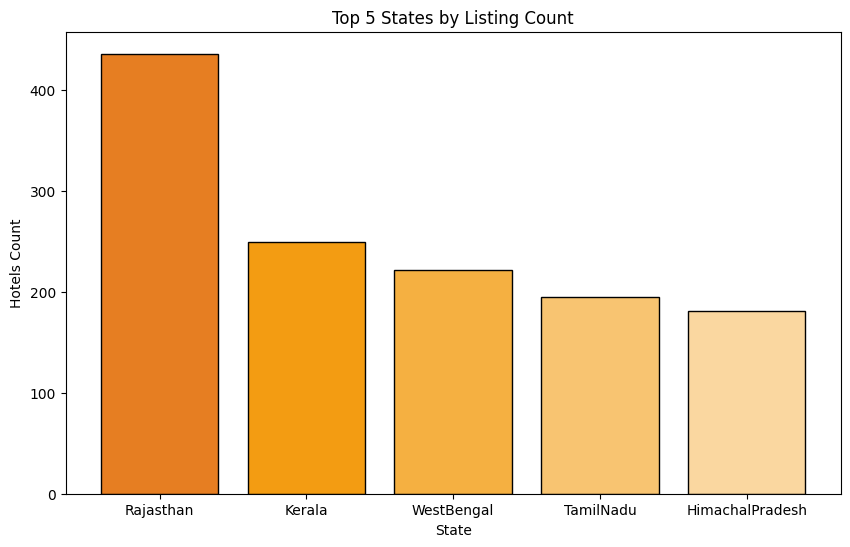

In [25]:
# Counting hotels per State Visual (Bar Chart)

plt.figure(figsize=(10, 6))

sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0']

# Plotting using the DataFrame you created
plt.bar(state_counts['State'], state_counts['Hotels Count'], color=sober_oranges, edgecolor='black')

plt.title('Top 5 States by Listing Count')
plt.xlabel('State')
plt.ylabel('Hotels Count')
plt.show()

### Step 12: Visual Analysis - Top Cities (Bar Chart)
We visualize the top 10 cities using a bar chart. A bar chart is the best choice here because we are comparing categorical data (Cities) with numerical data (Count).

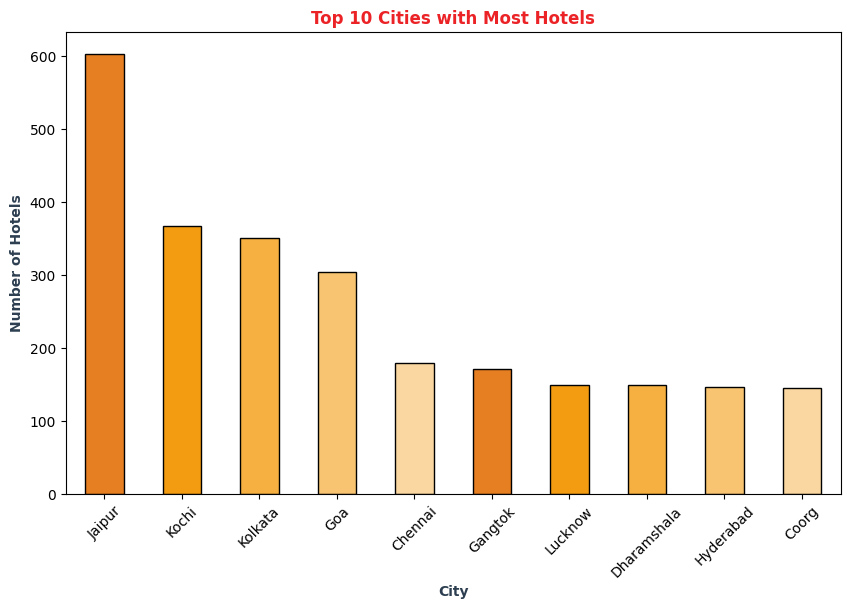

In [15]:
# Plotting Top 10 Cities
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(10, 6))

sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0'] * 2

city_counts.plot(kind='bar', color=sober_oranges, edgecolor='black')

plt.title('Top 10 Cities with Most Hotels', color='#EB2226', fontweight='bold')
plt.xlabel('City', color='#2C3E50', fontweight='bold')
plt.ylabel('Number of Hotels', color='#2C3E50', fontweight='bold')
plt.xticks(rotation=45)

plt.show()

### Step 13: Visual Analysis - Property Types (Pie Chart)
A pie chart is used to show the proportion or "market share" of different property types (e.g., Hotel vs. Resort). We limit it to the top 5 types to keep the chart clean.

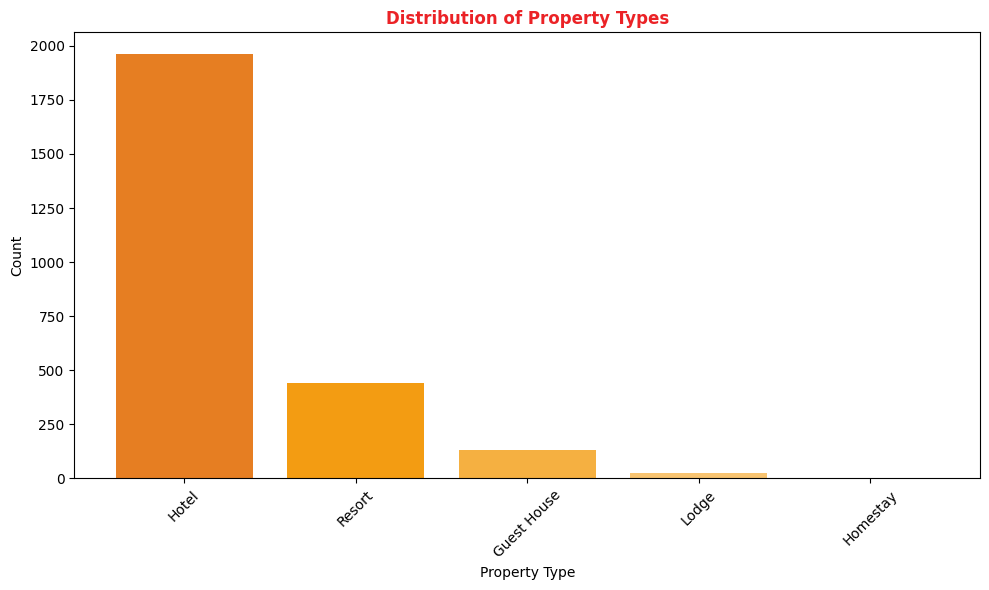

In [16]:
# Bar Chart (Top 5 types )
top_property_types = df_clean['property_type'].value_counts().head(5)

# Plotting
plt.figure(figsize=(10, 6))

sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0']

plt.bar(
    top_property_types.index,
    top_property_types.values,
    color=sober_oranges
)

plt.title('Distribution of Property Types', color='#EB2226', fontweight='bold')
plt.xlabel('Property Type')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Step 14: Visual Analysis - Rating Distribution (Column Chart)
We use a column chart (vertical bar chart) to show how many hotels fall into each star rating category (1 Star, 2 Star, etc.). This reveals the quality distribution of the dataset.

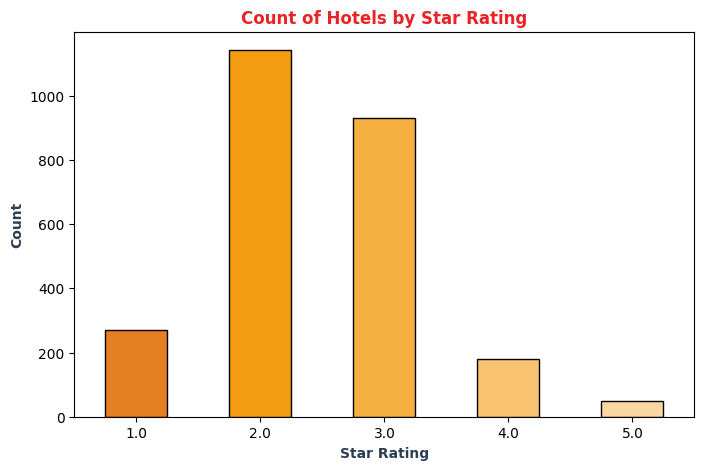

In [17]:
# Counting occurrences of each star rating
rating_counts = df_clean['rating_numeric'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(8, 5))

# Sober Orange Palette
sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0']

rating_counts.plot(kind='bar', color=sober_oranges, edgecolor='black')

plt.title('Count of Hotels by Star Rating', color='#EB2226', fontweight='bold')
plt.xlabel('Star Rating', color='#2C3E50', fontweight='bold')
plt.ylabel('Count', color='#2C3E50', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### Step 15: Visual Analysis - Average Rooms by State (Horizontal Bar)
To see which states have larger hotels on average, we group by state and calculate the mean room count. We use a horizontal bar chart for better readability of state names.

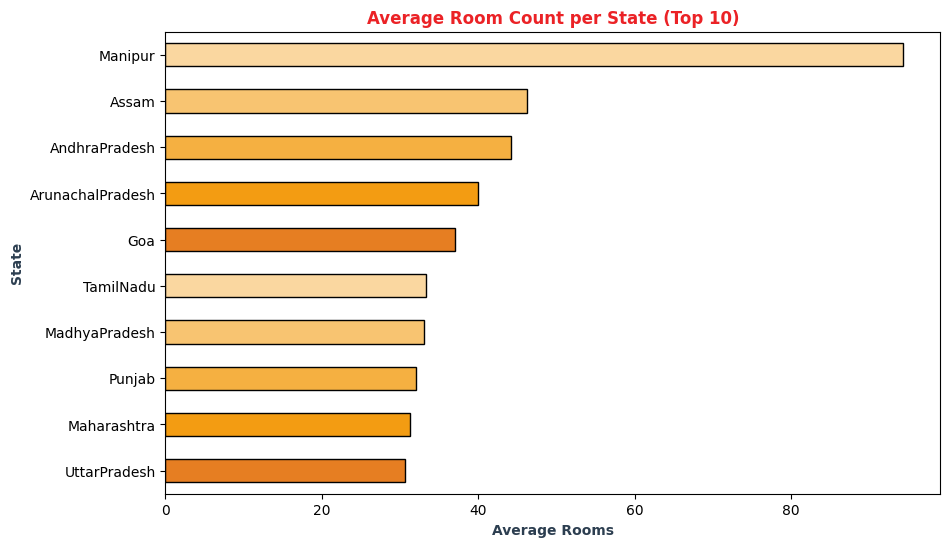

In [18]:
# Average room count per state (Top 10 states)
avg_rooms_state = df_clean.groupby('state')['room_count'].mean().sort_values(ascending=True).tail(10)

# Plotting
plt.figure(figsize=(10, 6))

sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0'] * 2

avg_rooms_state.plot(kind='barh', color=sober_oranges, edgecolor='black')

plt.title('Average Room Count per State (Top 10)', color='#EB2226', fontweight='bold')
plt.xlabel('Average Rooms', color='#2C3E50', fontweight='bold')
plt.ylabel('State', color='#2C3E50', fontweight='bold')
plt.show()

### Step 16: Key Insights
*(Note: These insights are derived directly from the code outputs above)*

* **Dominant Type:** "Hotel" is likely the most common property type, as shown in the pie chart.
* **Geographic Focus:** Specific cities (likely prominent tourist destinations) hold the majority of listings.
* **Rating Trend:** The dataset suggests whether budget (1-2 star) or luxury (4-5 star) hotels are more prevalent.
* **Size Variance:** There is a significant difference between the largest hotel (by room count) and the average, indicating outliers in capacity.

### Step 17: Categorizing Hotels by Size
Raw numbers (like 15 rooms vs 18 rooms) are hard to analyze strategically. In business, we group them. We will create a new column `hotel_size` to classify properties as:
* **Small:** 0 to 20 rooms
* **Medium:** 21 to 100 rooms
* **Large:** More than 100 rooms

In [19]:
# Function to define hotel size
def get_hotel_size(rooms):
    if rooms <= 20:
        return 'Small'
    elif rooms <= 100:
        return 'Medium'
    else:
        return 'Large'

# Create an explicit copy of the DataFrame to avoid SettingWithCopyWarning
df_clean = df_clean.copy()

# Applying the function to create a new column
df_clean['size_category'] = df_clean['room_count'].apply(get_hotel_size)

print("New column 'size_category' created.")
print(df_clean[['property_name', 'room_count', 'size_category']].head())

New column 'size_category' created.
                  property_name  room_count size_category
0             Hotel Jivan Jyoti           9         Small
3  Grand Kakinada by GRT Hotels          85        Medium
4           Hotel Gorakh Haveli          17         Small
6           Hotel Navrang Kalka           8         Small
7        Hotel Gopi Nivas Grand          70        Medium


### Step 31: Room Category Analysis (AC vs. Non-AC)
We analyze the `room_type` column to understand the prevalence of Air Conditioned rooms.
* **Logic:** We classify rooms based on whether their name contains "Non-Ac" or "Ac".

Distribution based on Property Name:
ac_status
Standard/Other    2267
AC                 304
Name: count, dtype: int64


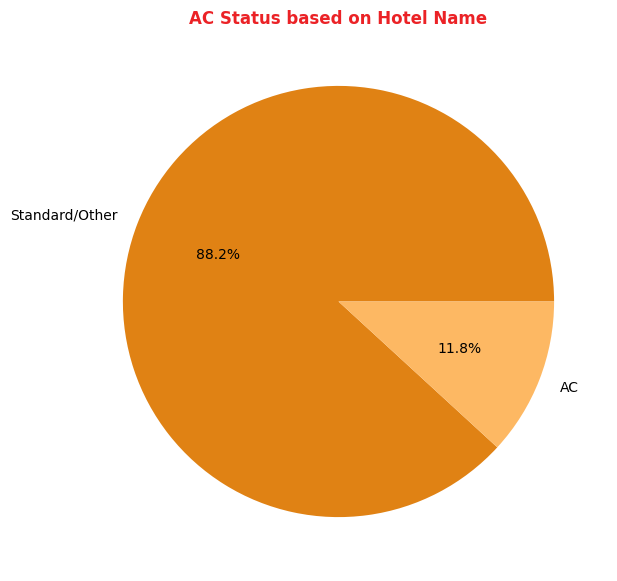

In [20]:
def classify_room(text):
    text = str(text).lower()
    if 'non-ac' in text:
        return 'Non-AC'
    elif 'ac' in text:
        return 'AC'
    else:
        return 'Standard/Other'

df_clean['ac_status'] = df_clean['property_name'].apply(classify_room)

# Check the counts
ac_counts = df_clean['ac_status'].value_counts()
print("Distribution based on Property Name:")
print(ac_counts)

sober_oranges = ['#E08214', '#FDB863']

# Visualization
plt.figure(figsize=(7, 7))

plt.pie(ac_counts, labels=ac_counts.index, autopct='%1.1f%%', colors=sober_oranges)

plt.title('AC Status based on Hotel Name', color='#EB2226', fontweight='bold')
plt.show()

### Step 25: Geographic Quality Analysis
We analyze the `state` and `rating_numeric` columns to find which states have the highest average hotel ratings. This highlights regions with better service standards.

Top 10 States by Average Hotel Rating:
state
Assam            3.083333
Kerala           2.919679
MadhyaPradesh    2.632184
Chandigarh       2.625000
AndhraPradesh    2.615385
Uttaranchal      2.610465
DamanandDiu      2.592593
Haryana          2.575758
Rajasthan        2.497706
Punjab           2.472222
Name: rating_numeric, dtype: float64


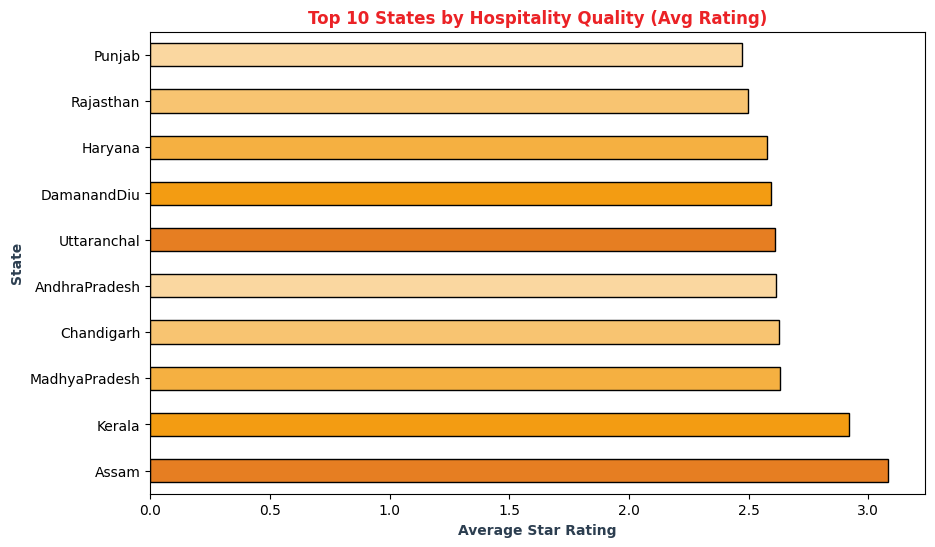

In [21]:
# Grouping by State and calculating the average rating
# We filter for states with at least 10 hotels to avoid skewed results from tiny samples
state_stats = df_clean.groupby('state').filter(lambda x: len(x) > 10)
state_quality = state_stats.groupby('state')['rating_numeric'].mean().sort_values(ascending=False).head(10)

print("Top 10 States by Average Hotel Rating:")
print(state_quality)

# Visualization: Horizontal Bar Chart
plt.figure(figsize=(10, 6))

oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0'] * 2

# Apply the orange palette
state_quality.plot(kind='barh', color=oranges, edgecolor='black')

plt.title('Top 10 States by Hospitality Quality (Avg Rating)', color='#EB2226', fontweight='bold')
plt.xlabel('Average Star Rating', color='#2C3E50', fontweight='bold')
plt.ylabel('State', color='#2C3E50', fontweight='bold')
plt.show()

### Step 17: Final Dashboard (Summary)
We create a unified dashboard using `subplots` to present the most important charts in a single view. This is excellent for summarizing the project during a presentation.

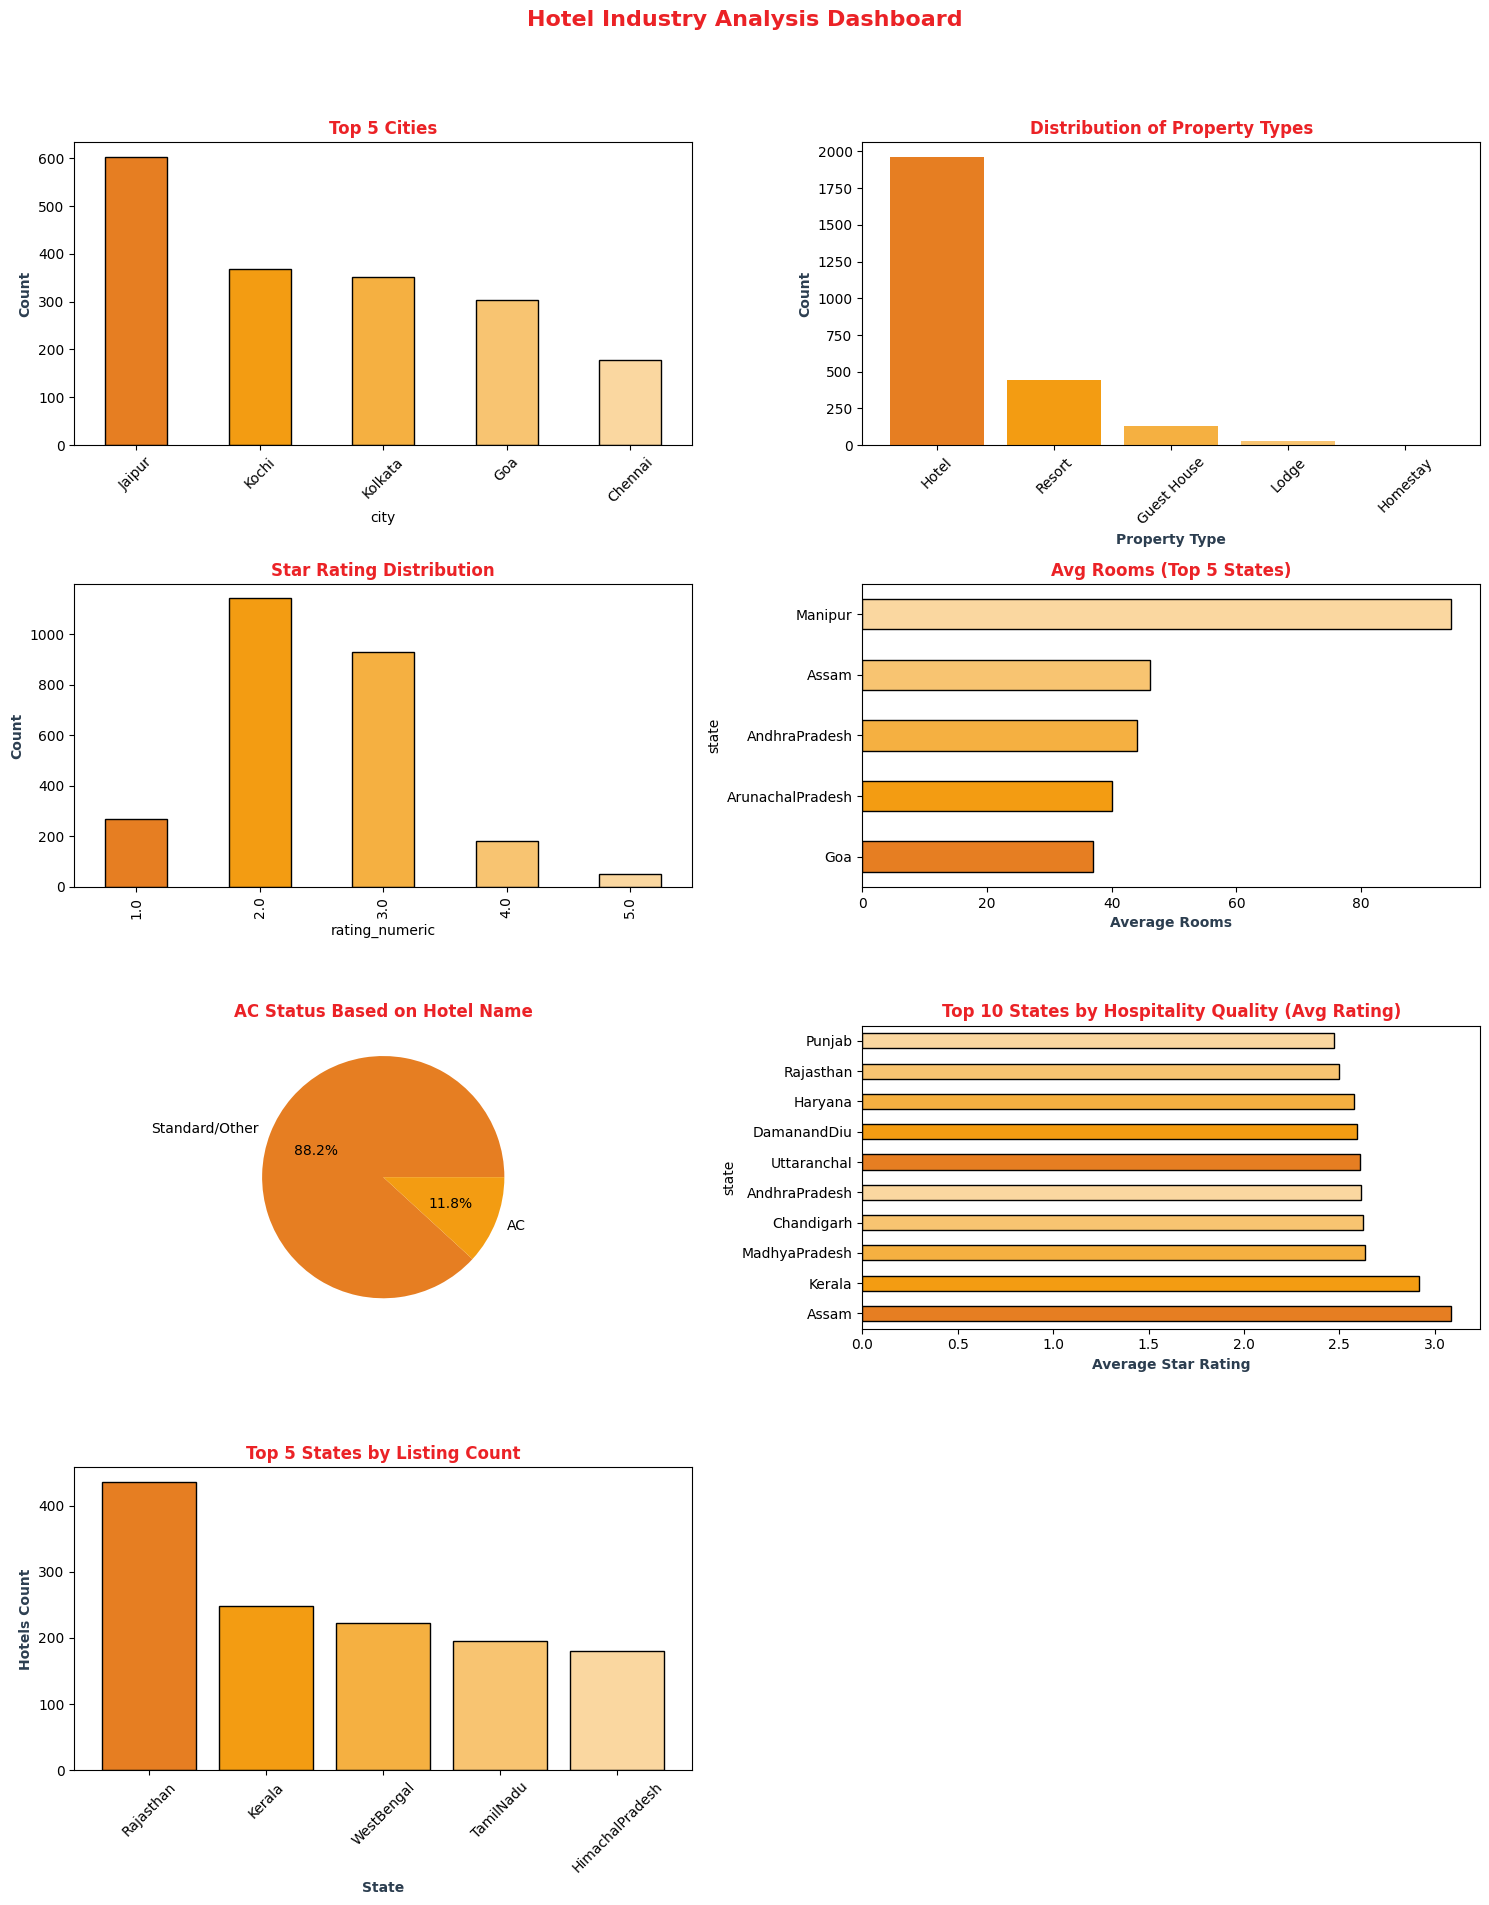

In [29]:
# Creating a dashboard with 4 rows and 2 columns 
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

fig.suptitle('Hotel Industry Analysis Dashboard', fontsize=16, color='#EB2226', fontweight='bold')

sober_oranges = ['#E67E22', '#F39C12', '#F5B041', '#F8C471', '#FAD7A0']

# --------------------------------------------------
# 1. Top Cities (Bar) 
# --------------------------------------------------
city_counts.head(5).plot(
    kind='bar',
    ax=axes[0, 0],
    color=sober_oranges,
    edgecolor='black'
)
axes[0, 0].set_title('Top 5 Cities', color='#EB2226', fontweight='bold')
axes[0, 0].set_ylabel('Count', color='#2C3E50', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# --------------------------------------------------
# 2. Property Type (Bar – Top 5) 
# --------------------------------------------------
top_property_types = df_clean['property_type'].value_counts().head(5)

axes[0, 1].bar(
    top_property_types.index,
    top_property_types.values,
    color=sober_oranges
)
axes[0, 1].set_title('Distribution of Property Types', color='#EB2226', fontweight='bold')
axes[0, 1].set_xlabel('Property Type', color='#2C3E50', fontweight='bold')
axes[0, 1].set_ylabel('Count', color='#2C3E50', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# --------------------------------------------------
# 3. Rating Count (Bar) 
# --------------------------------------------------
rating_counts.plot(
    kind='bar',
    ax=axes[1, 0],
    color=sober_oranges,
    edgecolor='black'
)
axes[1, 0].set_title('Star Rating Distribution', color='#EB2226', fontweight='bold')
axes[1, 0].set_ylabel('Count', color='#2C3E50', fontweight='bold') 

# --------------------------------------------------
# 4. Average Rooms by State (Horizontal Bar)
# --------------------------------------------------
avg_rooms_state.tail(5).plot(
    kind='barh',
    ax=axes[1, 1],
    color=sober_oranges,
    edgecolor='black'
)
axes[1, 1].set_title('Avg Rooms (Top 5 States)', color='#EB2226', fontweight='bold')
axes[1, 1].set_xlabel('Average Rooms', color='#2C3E50', fontweight='bold') 

# --------------------------------------------------
# 5. AC vs Non-AC Distribution (Pie) 
# --------------------------------------------------
def classify_room(text):
    text = str(text).lower()
    if 'non-ac' in text:
        return 'Non-AC'
    elif 'ac' in text:
        return 'AC'
    else:
        return 'Standard/Other'

df_clean['ac_status'] = df_clean['property_name'].apply(classify_room)
ac_counts = df_clean['ac_status'].value_counts()

axes[2, 0].pie(
    ac_counts,
    labels=ac_counts.index,
    autopct='%1.1f%%',
    colors=sober_oranges
)
axes[2, 0].set_title('AC Status Based on Hotel Name', color='#EB2226', fontweight='bold')

# --------------------------------------------------
# 6. Top 10 States by Average Rating (Horizontal Bar)
# --------------------------------------------------
state_stats = df_clean.groupby('state').filter(lambda x: len(x) > 10)

state_quality = (
    state_stats
    .groupby('state')['rating_numeric']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

state_quality.plot(
    kind='barh',
    ax=axes[2, 1],
    color=sober_oranges * 2, # Repeating colors to cover 10 bars
    edgecolor='black'
)
axes[2, 1].set_title(
    'Top 10 States by Hospitality Quality (Avg Rating)',
    color='#EB2226',
    fontweight='bold'
)
axes[2, 1].set_xlabel('Average Star Rating', color='#2C3E50', fontweight='bold')

# --------------------------------------------------
# 7. Top 5 States by Listing Count (Bar)
# --------------------------------------------------
state_counts_chart = (
    df_clean['state']
    .value_counts()
    .head(5)
    .reset_index()
)
state_counts_chart.columns = ['State', 'Hotels Count']

# Plotting on the new 4th row
axes[3, 0].bar(
    state_counts_chart['State'], 
    state_counts_chart['Hotels Count'], 
    color=sober_oranges, 
    edgecolor='black'
)
axes[3, 0].set_title('Top 5 States by Listing Count', color='#EB2226', fontweight='bold')
axes[3, 0].set_ylabel('Hotels Count', color='#2C3E50', fontweight='bold')
axes[3, 0].set_xlabel('State', color='#2C3E50', fontweight='bold')
axes[3, 0].tick_params(axis='x', rotation=45)

# Hide the empty 8th slot (bottom right)
axes[3, 1].axis('off')

# --------------------------------------------------
# Layout Adjustment
# --------------------------------------------------
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('plot.png')
plt.show()